In [1]:
# 必要なパッケージのインストール
%pip install "transformers>=4.57.0" accelerate "torch==2.8.0" "torchvision" pillow requests python-dotenv numpy scikit-learn matplotlib seaborn "qwen-vl-utils>=0.0.14" easyocr -q

# 公式のQwen3VLEmbedderクラスをインストール
!mkdir -p scripts
!wget -q https://huggingface.co/Qwen/Qwen3-VL-Embedding-8B/resolve/main/scripts/qwen3_vl_embedding.py -O scripts/qwen3_vl_embedding.py

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 887.9/887.9 MB 1.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.4/322.4 MB 8.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 MB 16.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 91.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 108.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 MB 50.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 74.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 32.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchaudio 2.10.0+cu128 requires torch==2.10.0, but y

In [2]:
import torch
import gc

# メモリをクリア
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")


PyTorch version: 2.8.0+cu128
CUDA available: True
CUDA device: NVIDIA A100-SXM4-80GB
GPU Memory: 79.25 GB


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
SAVE_DIR = "/content/drive/MyDrive/genAI/with_ocr_results"
os.makedirs(SAVE_DIR, exist_ok=True)
print("save dir:", SAVE_DIR)

In [3]:
import requests
import os 
import re
import io
from PIL import Image


messageIds = [
    "019b2a64-eebc-7815-84c5-e384fabc495c", #ictトラブルシューティング予選結果
    "019a48ff-b175-783c-93fc-b4ec6731dde5", #TechBookの販売記録
    "019bb6b8-5c57-7d1f-8b93-297c8e6c7827", #ポータブルモニターを購入
    "019bb5c0-5409-7b3b-ba9b-07449030364a", #大学の課題の締め切り
    "019bd043-d86c-79b8-9cf1-11351a482267", #pcの空き容量の画像
    "0197c4ef-8be2-792e-922b-c498b6948775", #traqの9点リーダーのアイコン
    "01963951-0f55-75b5-a53b-07f467ad9051", #sysad体験会
    "0195be37-dea6-7902-8d04-e46185873108", #githubへの招待
    "019bde55-0ca0-7d7a-95ab-0a1c3bf5eeaa", #僕のgithub
    "019bde55-b166-7d7b-b290-2f049f72fe08", #googleの検索画面
    "019bbd0d-5e27-77b2-8494-42499697c033", #大学の課題をやろうとしてる。reportのpdf画像　やるぞ～と言ってる
    "019bde84-1609-7dc5-b8fc-f2c77bcdb005", #食べ物の画像すき焼き弁当
    "019bdeb4-6ec8-7e0e-b773-3bec85c35584", #タイピングチャレンジ
    "019bb65e-9263-7c89-b123-95389f4414cd", #猫
    "019b8cea-695d-7047-aafb-793c58d25eff", #仮想通貨
]



def _get_session() -> requests.Session:
    r_session = os.getenv("r_session")
    if not r_session:
        raise RuntimeError("r_session が見つかりません（環境変数を設定してください）")
    
    session = requests.Session()
    session.cookies.set("r_session", r_session)
    return session


# messageidの配列を受け取り、メッセージの配列を返す
def get_messages_and_images():
    BASE_URL = "https://q.trap.jp/api/v3"
    _FILE_URL_RE = re.compile(r"https?://q\.trap\.jp/files/([0-9a-fA-F-]+)")
    
    messages_result = []
    images_result = []
    
    with _get_session() as session:
        for message_id in messageIds:
            
            try:
                response = session.get(f"{BASE_URL}/messages/{message_id}")
                response.raise_for_status()
                content = response.json()["content"]

                """
                画像のurlを抽出
                メッセージのcontentからファイルIDを抽出
                画像はcontentの中にhttps://q.trap.jp/files/019b2a64-ee12-7815-9d3c-4c510250218aのような形式で保存されている
                """
                image_file_ids = _FILE_URL_RE.findall(content)

                imgs = []

                for image_file_id in image_file_ids:
                    response = session.get(f"{BASE_URL}/files/{image_file_id}")
                    response.raise_for_status()
                    img_bytes = response.content
                    pil_img = Image.open(io.BytesIO(img_bytes)).convert("RGB")
                    imgs.append(pil_img)


                # content内にある 画像のurlを削除 (embeddingにurlは不要なため)
                processed_text = _FILE_URL_RE.sub("", content).strip()

                messages_result.append(processed_text)
                images_result.append(imgs)
            except requests.exceptions.RequestException as e:
                print(f"Error fetching message {message_id}: {e}")
    
    return messages_result, images_result


In [4]:
# traQ APIのセッション情報を設定
# vscodeだと.envが使えない？
import os

r_session = input("r_sessionを入力してください: ").strip()
if r_session:
    os.environ["r_session"] = r_session
    print("r_sessionを設定しました")
else:
    print("警告: r_sessionが設定されていません")

r_sessionを設定しました


In [6]:
import easyocr
import numpy as np

# 取得
messages, images = get_messages_and_images()
print(f"取得したメッセージ数: {len(messages)}")
print(f"画像ありメッセージ数: {sum(1 for imgs in images if len(imgs) > 0)}")

# EasyOCR reader
reader = easyocr.Reader(
    ['ja', 'en'],
    # gpu=torch.cuda.is_available(),
    download_enabled=True,
)

def upscale_for_ocr(pil_img: Image.Image, scale: int = 2) -> Image.Image:
    """小さい文字対策：2倍くらいに拡大してからOCR"""
    w, h = pil_img.size
    return pil_img.resize((w * scale, h * scale), Image.BICUBIC)

def ocr_pil_image(
    pil_img: Image.Image,
    scale: int = 2,
    conf_th: float = 0.4,
    max_chars: int = 100,
) -> str:
    img2 = upscale_for_ocr(pil_img.convert("RGB"), scale=scale)
    arr = np.array(img2)

    # results: List[(bbox, text, conf)]
    results = reader.readtext(arr, detail=1, paragraph=False)

    lines = []
    for _bbox, text, conf in results:
        if conf < conf_th:
            continue
        t = str(text).strip()
        if not t:
            continue
        # ありがちなノイズを軽く潰す（必要なら消してOK）
        t = re.sub(r"\s+", " ", t)
        lines.append(t)

    # 重複除去（順序維持）
    uniq = []
    seen = set()
    for t in lines:
        if t in seen:
            continue
        seen.add(t)
        uniq.append(t)

    ocr_text = "\n".join(uniq).strip()
    if len(ocr_text) > max_chars:
        ocr_text = ocr_text[:max_chars] + "…"
    return ocr_text


import numpy as np

documents = []
labels = []
doc_to_msg_idx = []
ocr_texts = []
thumbnails = []

THUMB_SIZE = 200

for m_idx, (msg_text, imgs) in enumerate(zip(messages, images), start=1):
    for i_idx, img in enumerate(imgs, start=1):
        ocr_text = ocr_pil_image(img, scale=2, conf_th=0.4, max_chars=200)

        text_aug = msg_text
        if ocr_text:
            text_aug = f"{msg_text}\n[OCR]\n{ocr_text}"

        # embedding用
        documents.append({"text": text_aug, "image": img})

        # 可視化用（doc順に揃う）
        labels.append(f"M{m_idx}-I{i_idx}")
        doc_to_msg_idx.append(m_idx - 1)   # messagesのindex（0始まり）
        ocr_texts.append(ocr_text)

        thumb = img.copy()
        thumb.thumbnail((THUMB_SIZE, THUMB_SIZE))
        thumbnails.append(np.array(thumb))

print("documents:", len(documents))
print("labels:", len(labels))
print("doc_to_msg_idx:", len(doc_to_msg_idx))
print("ocr_texts:", len(ocr_texts))
print("thumbnails:", len(thumbnails))

assert len(documents) == len(labels) == len(doc_to_msg_idx) == len(ocr_texts) == len(thumbnails)


del reader; gc.collect(); torch.cuda.empty_cache()
print(f"documents: {len(documents)} (画像ごとに1doc)")
print(f"ocr saved to: out/ocr_M*-I*.txt")


# ---------------------------
# クエリと結合して embedding に流す
# ---------------------------
query_texts = [
    "github",
    "pc",
    "モニター",
    "TechBook",
    "SysAd",
    "新入生",
    "大学の教室に学生がたくさんいてスライドを見ている",
    "スライド",
    "大学",
    "教室",
    "アイコン",
    "タイピング",
    "成功",
    "テスト",
    "紙",
    "mumumu",
    "google",
    "googleのロゴが左上にありqwen3-vlについて検索してる",
    "大学の課題をやろうとしてる",
    "やる気がある",
    "ごはん",
    "駅弁",
    "すきやき",
    "猫",
    "かわいい",
    "仮想通貨",
    "チャート"
]
queries = [{"text": q} for q in query_texts]

inputs = queries + documents
print(f"queries: {len(queries)} / documents: {len(documents)} / total inputs: {len(inputs)}")


取得したメッセージ数: 15
画像ありメッセージ数: 15
documents: 20
labels: 20
doc_to_msg_idx: 20
ocr_texts: 20
thumbnails: 20
documents: 20 (画像ごとに1doc)
ocr saved to: out/ocr_M*-I*.txt
queries: 27 / documents: 20 / total inputs: 47


In [7]:
from scripts.qwen3_vl_embedding import Qwen3VLEmbedder
import torch

model_name_or_path = "Qwen/Qwen3-VL-Embedding-8B"

model = Qwen3VLEmbedder(
    model_name_or_path=model_name_or_path,
    torch_dtype=torch.float16,
    # attn_implementation="flash_attention_2",　これがあるとうまくいかない
)

print("model loaded")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/749 [00:00<?, ?it/s]

...

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/613 [00:00<?, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/817 [00:00<?, ?B/s]

model loaded


In [8]:
print("embedding を生成中...")
print(f"  クエリ数: {len(queries)}")
print(f"  ドキュメント数: {len(documents)}")
print(f"  合計: {len(inputs)}")

embeddings = model.process(inputs)

# クエリとドキュメントの類似度を計算
num_queries = len(queries)
similarity_scores = (embeddings[:num_queries] @ embeddings[num_queries:].T)
print(f"\n類似度スコア shape: {similarity_scores.shape}")
print(similarity_scores.tolist())

embedding を生成中...
  クエリ数: 27
  ドキュメント数: 20
  合計: 47

類似度スコア shape: torch.Size([27, 20])
[[0.246337890625, 0.1881103515625, 0.1995849609375, 0.31494140625, 0.2010498046875, 0.257080078125, 0.23681640625, 0.296142578125, 0.291748046875, 0.259521484375, 0.28173828125, 0.424072265625, 0.41162109375, 0.295166015625, 0.1746826171875, 0.06915283203125, 0.1734619140625, 0.2203369140625, 0.2154541015625, 0.1595458984375], [0.1925048828125, 0.194580078125, 0.29541015625, 0.29638671875, 0.1424560546875, 0.271240234375, 0.296142578125, 0.254638671875, 0.257568359375, 0.2432861328125, 0.2479248046875, 0.228271484375, 0.1961669921875, 0.215576171875, 0.154541015625, 0.025390625, 0.10748291015625, 0.1885986328125, 0.18798828125, 0.1329345703125], [0.2088623046875, 0.2196044921875, 0.460205078125, 0.39501953125, 0.193359375, 0.2578125, 0.27734375, 0.2481689453125, 0.334716796875, 0.31787109375, 0.308349609375, 0.2100830078125, 0.198486328125, 0.283935546875, 0.15771484375, 0.10516357421875, 0.16857910

In [9]:
# 類似度マトリックスの可視化
import numpy as np
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity


# documentsのembeddingだけを取得（queriesは除外）
num_queries = len(queries)
documents_embeddings = embeddings[num_queries:]

print(f"Documents数: {len(documents_embeddings)}")
print(f"Embedding次元数: {documents_embeddings.shape[1]}")

# 類似度マトリックスを計算
print("\n類似度マトリックスを計算中...")
similarity_matrix = cosine_similarity(documents_embeddings.cpu().numpy())

print(f"類似度マトリックスの形状: {similarity_matrix.shape}")
print(f"類似度の範囲: min={similarity_matrix.min():.4f}, max={similarity_matrix.max():.4f}")
print(f"平均類似度: {similarity_matrix.mean():.4f}")

Documents数: 20
Embedding次元数: 4096

類似度マトリックスを計算中...
類似度マトリックスの形状: (20, 20)
類似度の範囲: min=0.0623, max=1.0000
平均類似度: 0.3008


In [11]:
# ヒートマップで可視化
import warnings

# 日本語フォントの設定（Google Colab用）
import subprocess
subprocess.run(['apt-get', 'install', '-y', 'fonts-noto-cjk'], capture_output=True)

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager

# フォントキャッシュをクリアして再構築
font_manager.fontManager.addfont('/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc')
matplotlib.rcParams['font.family'] = 'Noto Sans CJK JP'

# フォント関連の警告を抑制
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')

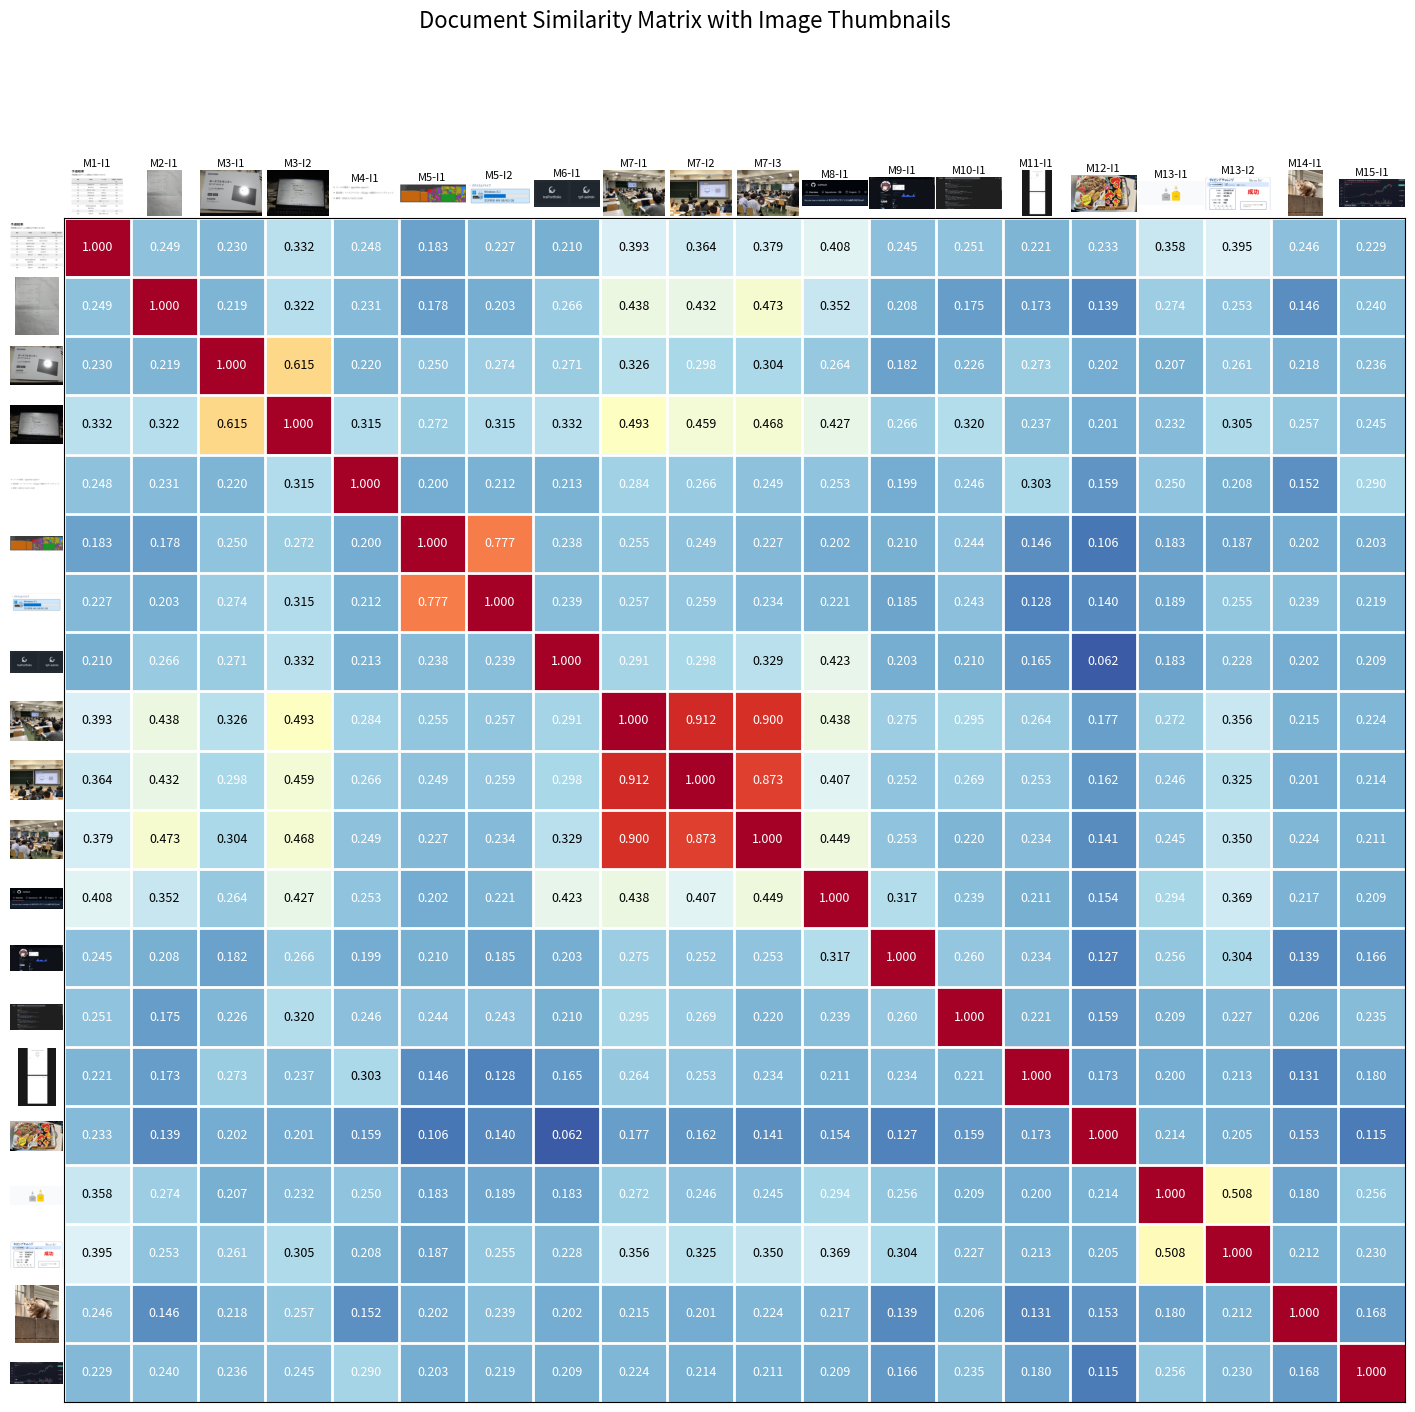

In [12]:
# 画像サムネイル付きヒートマップ（messages.pyの実装を参考）
import matplotlib.gridspec as gridspec
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# 画像サムネイルを準備（表示用：高画質にするため大きめにリサイズ）
# 注意：LLMに渡している画像は元のサイズのままです

thumbnails = []
for idx, (text, imgs) in enumerate(zip(messages, images)):
    if imgs:
        for img in imgs:
            # サムネイルサイズにリサイズ（コピーを作成）
            # 画質を良くするため、200x200に拡大（元は60x60）
            thumb = img.copy()
            thumb.thumbnail((200, 200))
            thumbnails.append(np.array(thumb))
    else:
        # 画像がない場合は空の画像を作成
        thumbnails.append(np.ones((200, 200, 3), dtype=np.uint8) * 200)

num_docs = len(documents_embeddings)

# グリッドスペックを使用してレイアウトを作成
fig_img = plt.figure(figsize=(18, 16))
gs = gridspec.GridSpec(
    num_docs + 1, num_docs + 1,
    figure=fig_img,
    width_ratios=[0.8] + [1] * num_docs,
    height_ratios=[0.8] + [1] * num_docs,
    hspace=0.02, wspace=0.02
)

# 左上の空白
ax_corner = fig_img.add_subplot(gs[0, 0])
ax_corner.axis('off')

# 上部の画像（列ラベル）
for i in range(num_docs):
    ax_top = fig_img.add_subplot(gs[0, i + 1])
    ax_top.imshow(thumbnails[i])
    ax_top.axis('off')
    ax_top.set_title(labels[i], fontsize=8, pad=2)

# 左側の画像（行ラベル）
for i in range(num_docs):
    ax_left = fig_img.add_subplot(gs[i + 1, 0])
    ax_left.imshow(thumbnails[i])
    ax_left.axis('off')
    ax_left.set_ylabel(labels[i], fontsize=8, rotation=0, labelpad=10)

# ヒートマップのメイン部分
ax_main = fig_img.add_subplot(gs[1:, 1:])

# ヒートマップを描画
im = ax_main.imshow(
    similarity_matrix,
    cmap='RdYlBu_r',
    vmin=0,
    vmax=1,
    aspect='auto'
)

# 各セルに数値を表示
for i in range(num_docs):
    for j in range(num_docs):
        text_color = "black" if 0.3 < similarity_matrix[i, j] < 0.7 else "white"
        ax_main.text(
            j, i, f'{similarity_matrix[i, j]:.3f}',
            ha="center", va="center",
            color=text_color,
            fontsize=9
        )

# グリッド線を追加
ax_main.set_xticks(np.arange(num_docs) - 0.5, minor=True)
ax_main.set_yticks(np.arange(num_docs) - 0.5, minor=True)
ax_main.grid(which="minor", color="white", linestyle='-', linewidth=2)
ax_main.tick_params(which="minor", size=0)

# メジャーティックを非表示
ax_main.set_xticks([])
ax_main.set_yticks([])



plt.suptitle('Document Similarity Matrix with Image Thumbnails', fontsize=16, y=0.98)
plt.show()


In [13]:
# 統計情報と類似度が高いペアを表示（同じテキストのペアは除外）
print("=== 類似度マトリックスの統計情報 ===")
print(f"平均類似度: {similarity_matrix.mean():.4f}")
print(f"標準偏差: {similarity_matrix.std():.4f}")

# 各ドキュメントが属するメッセージインデックスを取得
doc_to_msg_idx = []
for idx, (text, imgs) in enumerate(zip(messages, images)):
    for _ in imgs:
        doc_to_msg_idx.append(idx)

# 対角成分と同じメッセージのペアをマスク
masked_matrix = similarity_matrix.copy()
np.fill_diagonal(masked_matrix, -1)

# 同じメッセージ（同じテキスト）のペアもマスク
for i in range(len(masked_matrix)):
    for j in range(len(masked_matrix)):
        if doc_to_msg_idx[i] == doc_to_msg_idx[j]:
            masked_matrix[i, j] = -1

max_similarity = np.max(masked_matrix)
min_similarity = np.min(masked_matrix[masked_matrix >= 0])  # -1を除外

print(f"最大類似度（異なるメッセージ間）: {max_similarity:.4f}")
print(f"最小類似度: {min_similarity:.4f}")

# 最も類似度が高いペアを表示（上位10組、同じテキストは除外）
print("\n=== 最も類似度が高いペア（上位10組、同じテキスト除外） ===")
flat_indices = np.argsort(masked_matrix.flatten())[::-1]

count = 0
seen_pairs = set()  # 重複ペアを避ける
for flat_idx in flat_indices:
    if count >= 10:
        break
    
    row = flat_idx // len(similarity_matrix)
    col = flat_idx % len(similarity_matrix)
    similarity = masked_matrix[row, col]
    
    if similarity < 0:  # マスクされた値はスキップ
        continue
    
    # 順序を正規化して重複を避ける
    pair = tuple(sorted([row, col]))
    if pair in seen_pairs:
        continue
    seen_pairs.add(pair)
    
    count += 1
    
    label1 = labels[row]
    label2 = labels[col]
    msg_idx1 = doc_to_msg_idx[row]
    msg_idx2 = doc_to_msg_idx[col]
    
    print(f"\n[{count}] 類似度: {similarity:.4f}")
    print(f"  {label1} vs {label2}")
    
    text1 = messages[msg_idx1][:60] + "..." if len(messages[msg_idx1]) > 60 else messages[msg_idx1]
    text2 = messages[msg_idx2][:60] + "..." if len(messages[msg_idx2]) > 60 else messages[msg_idx2]
    print(f"  テキスト1: {text1}")
    print(f"  テキスト2: {text2}")


=== 類似度マトリックスの統計情報 ===
平均類似度: 0.3008
標準偏差: 0.1989
最大類似度（異なるメッセージ間）: 0.4930
最小類似度: 0.0623

=== 最も類似度が高いペア（上位10組、同じテキスト除外） ===

[1] 類似度: 0.4930
  M3-I2 vs M7-I1
  テキスト1: ポータブルモニターを購入して、部室に置きました
  テキスト2: SysAd体験会、約40人が来てくれて無事実施することができました！
mysql問題は本当にごめんなさい:bow-nya...

[2] 類似度: 0.4725
  M7-I3 vs M2-I1
  テキスト1: SysAd体験会、約40人が来てくれて無事実施することができました！
mysql問題は本当にごめんなさい:bow-nya...
  テキスト2: TechBookの販売記録です

[3] 類似度: 0.4678
  M7-I3 vs M3-I2
  テキスト1: SysAd体験会、約40人が来てくれて無事実施することができました！
mysql問題は本当にごめんなさい:bow-nya...
  テキスト2: ポータブルモニターを購入して、部室に置きました

[4] 類似度: 0.4585
  M3-I2 vs M7-I2
  テキスト1: ポータブルモニターを購入して、部室に置きました
  テキスト2: SysAd体験会、約40人が来てくれて無事実施することができました！
mysql問題は本当にごめんなさい:bow-nya...

[5] 類似度: 0.4491
  M7-I3 vs M8-I1
  テキスト1: SysAd体験会、約40人が来てくれて無事実施することができました！
mysql問題は本当にごめんなさい:bow-nya...
  テキスト2: 入れました！ありがとうございます！

[6] 類似度: 0.4382
  M7-I1 vs M2-I1
  テキスト1: SysAd体験会、約40人が来てくれて無事実施することができました！
mysql問題は本当にごめんなさい:bow-nya...
  テキスト2: TechBookの販売記録です

[7] 類似度: 0.4378
  M7-I1 vs M8-I1
  テキスト1: SysAd体験会、約40人が

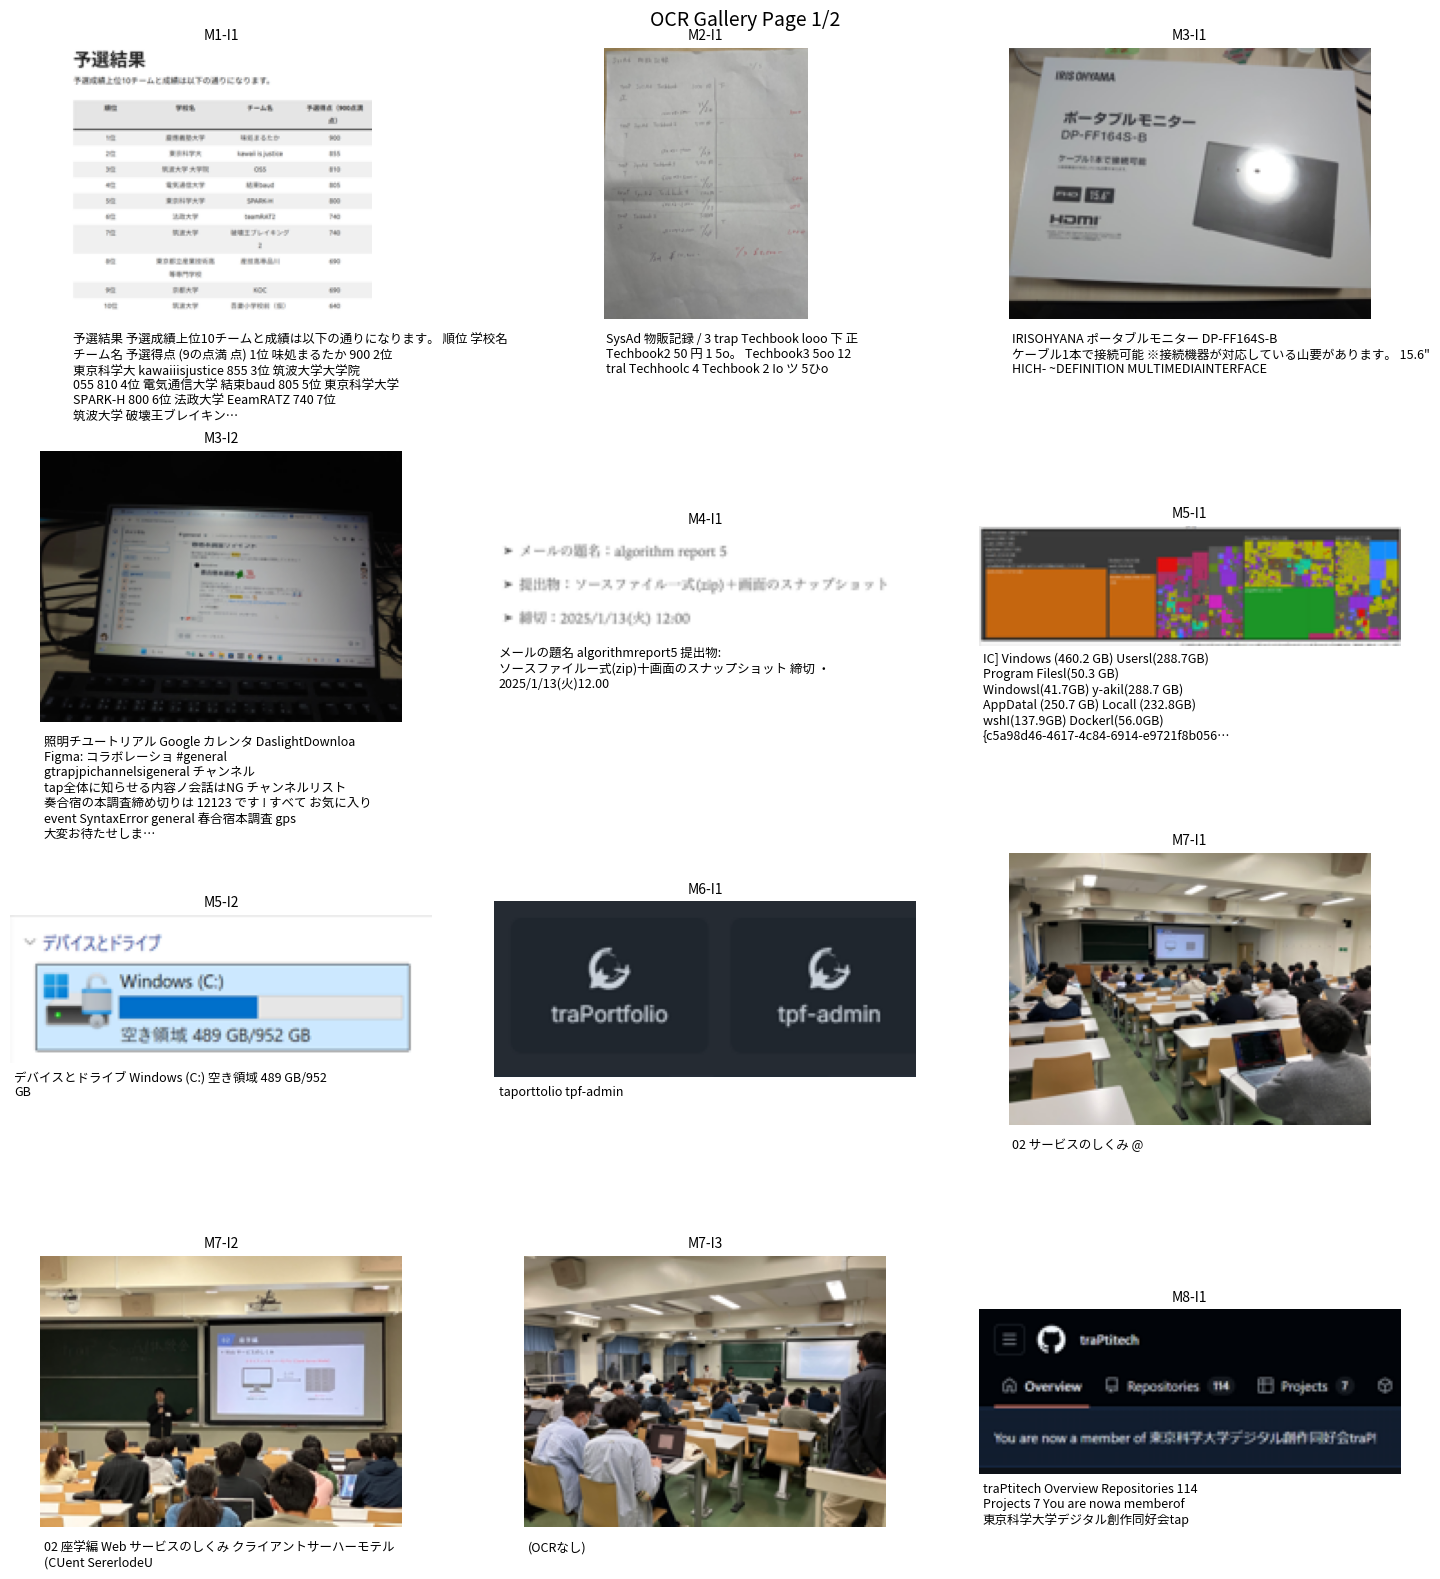

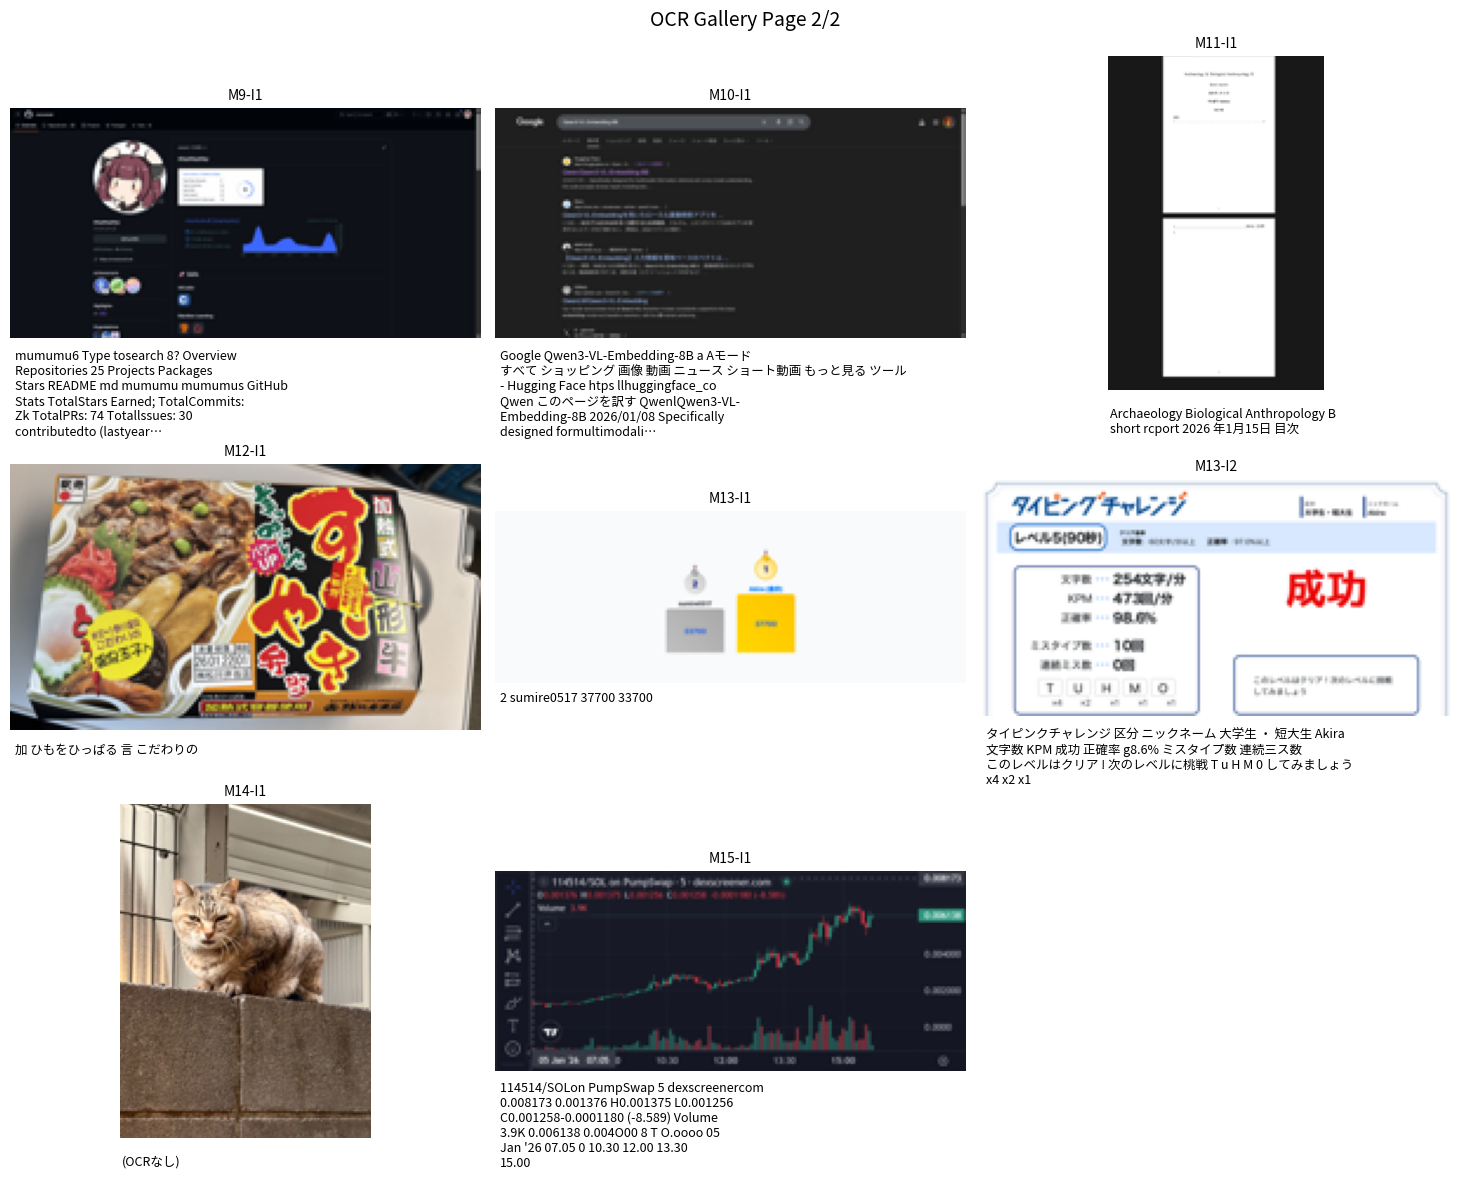

In [ ]:
import matplotlib.gridspec as gridspec
import textwrap
import numpy as np
import matplotlib.pyplot as plt

query_doc_similarity = similarity_scores.cpu().numpy()
top_k = 3

for q_idx, query_text in enumerate(query_texts):
    scores = query_doc_similarity[q_idx]
    top_indices = np.argsort(scores)[::-1][:top_k]

    fig = plt.figure(figsize=(16, 4))
    gs = gridspec.GridSpec(1, top_k + 1, width_ratios=[1.5] + [1] * top_k, wspace=0.3)

    ax_query = fig.add_subplot(gs[0, 0])
    ax_query.text(
        0.5, 0.5, f"Query:\n\n{query_text}",
        ha='center', va='center', fontsize=12,
        wrap=True, bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8)
    )
    ax_query.axis('off')
    ax_query.set_title(f"Query {q_idx + 1}", fontsize=14, fontweight='bold')

    for rank, doc_idx in enumerate(top_indices):
        ax = fig.add_subplot(gs[0, rank + 1])

        if doc_idx < len(thumbnails):
            ax.imshow(thumbnails[doc_idx])

        # 投稿本文（短縮）
        msg_idx = doc_to_msg_idx[doc_idx]
        msg_preview = messages[msg_idx].replace("\n", " ")
        msg_preview = msg_preview[:40] + "..." if len(msg_preview) > 40 else msg_preview

        # OCR（短縮）
        ocr_preview = ""
        if doc_idx < len(ocr_texts) and ocr_texts[doc_idx]:
            ocr_preview = ocr_texts[doc_idx].replace("\n", " / ")
            ocr_preview = (ocr_preview[:80] + "…") if len(ocr_preview) > 80 else ocr_preview

        caption = f"{msg_preview}\nOCR: {ocr_preview}" if ocr_preview else msg_preview

        score = scores[doc_idx]
        ax.set_title(f"#{rank+1} Score: {score:.3f}\n{labels[doc_idx]}", fontsize=10)
        ax.set_xlabel(textwrap.fill(caption, width=28), fontsize=8)

        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

        for spine in ax.spines.values():
            spine.set_color('red' if score > 0.4 else 'orange' if score > 0.3 else 'gray')
            spine.set_linewidth(3 if score > 0.4 else 2)

    plt.tight_layout()
    plt.show()
    print("-" * 80)

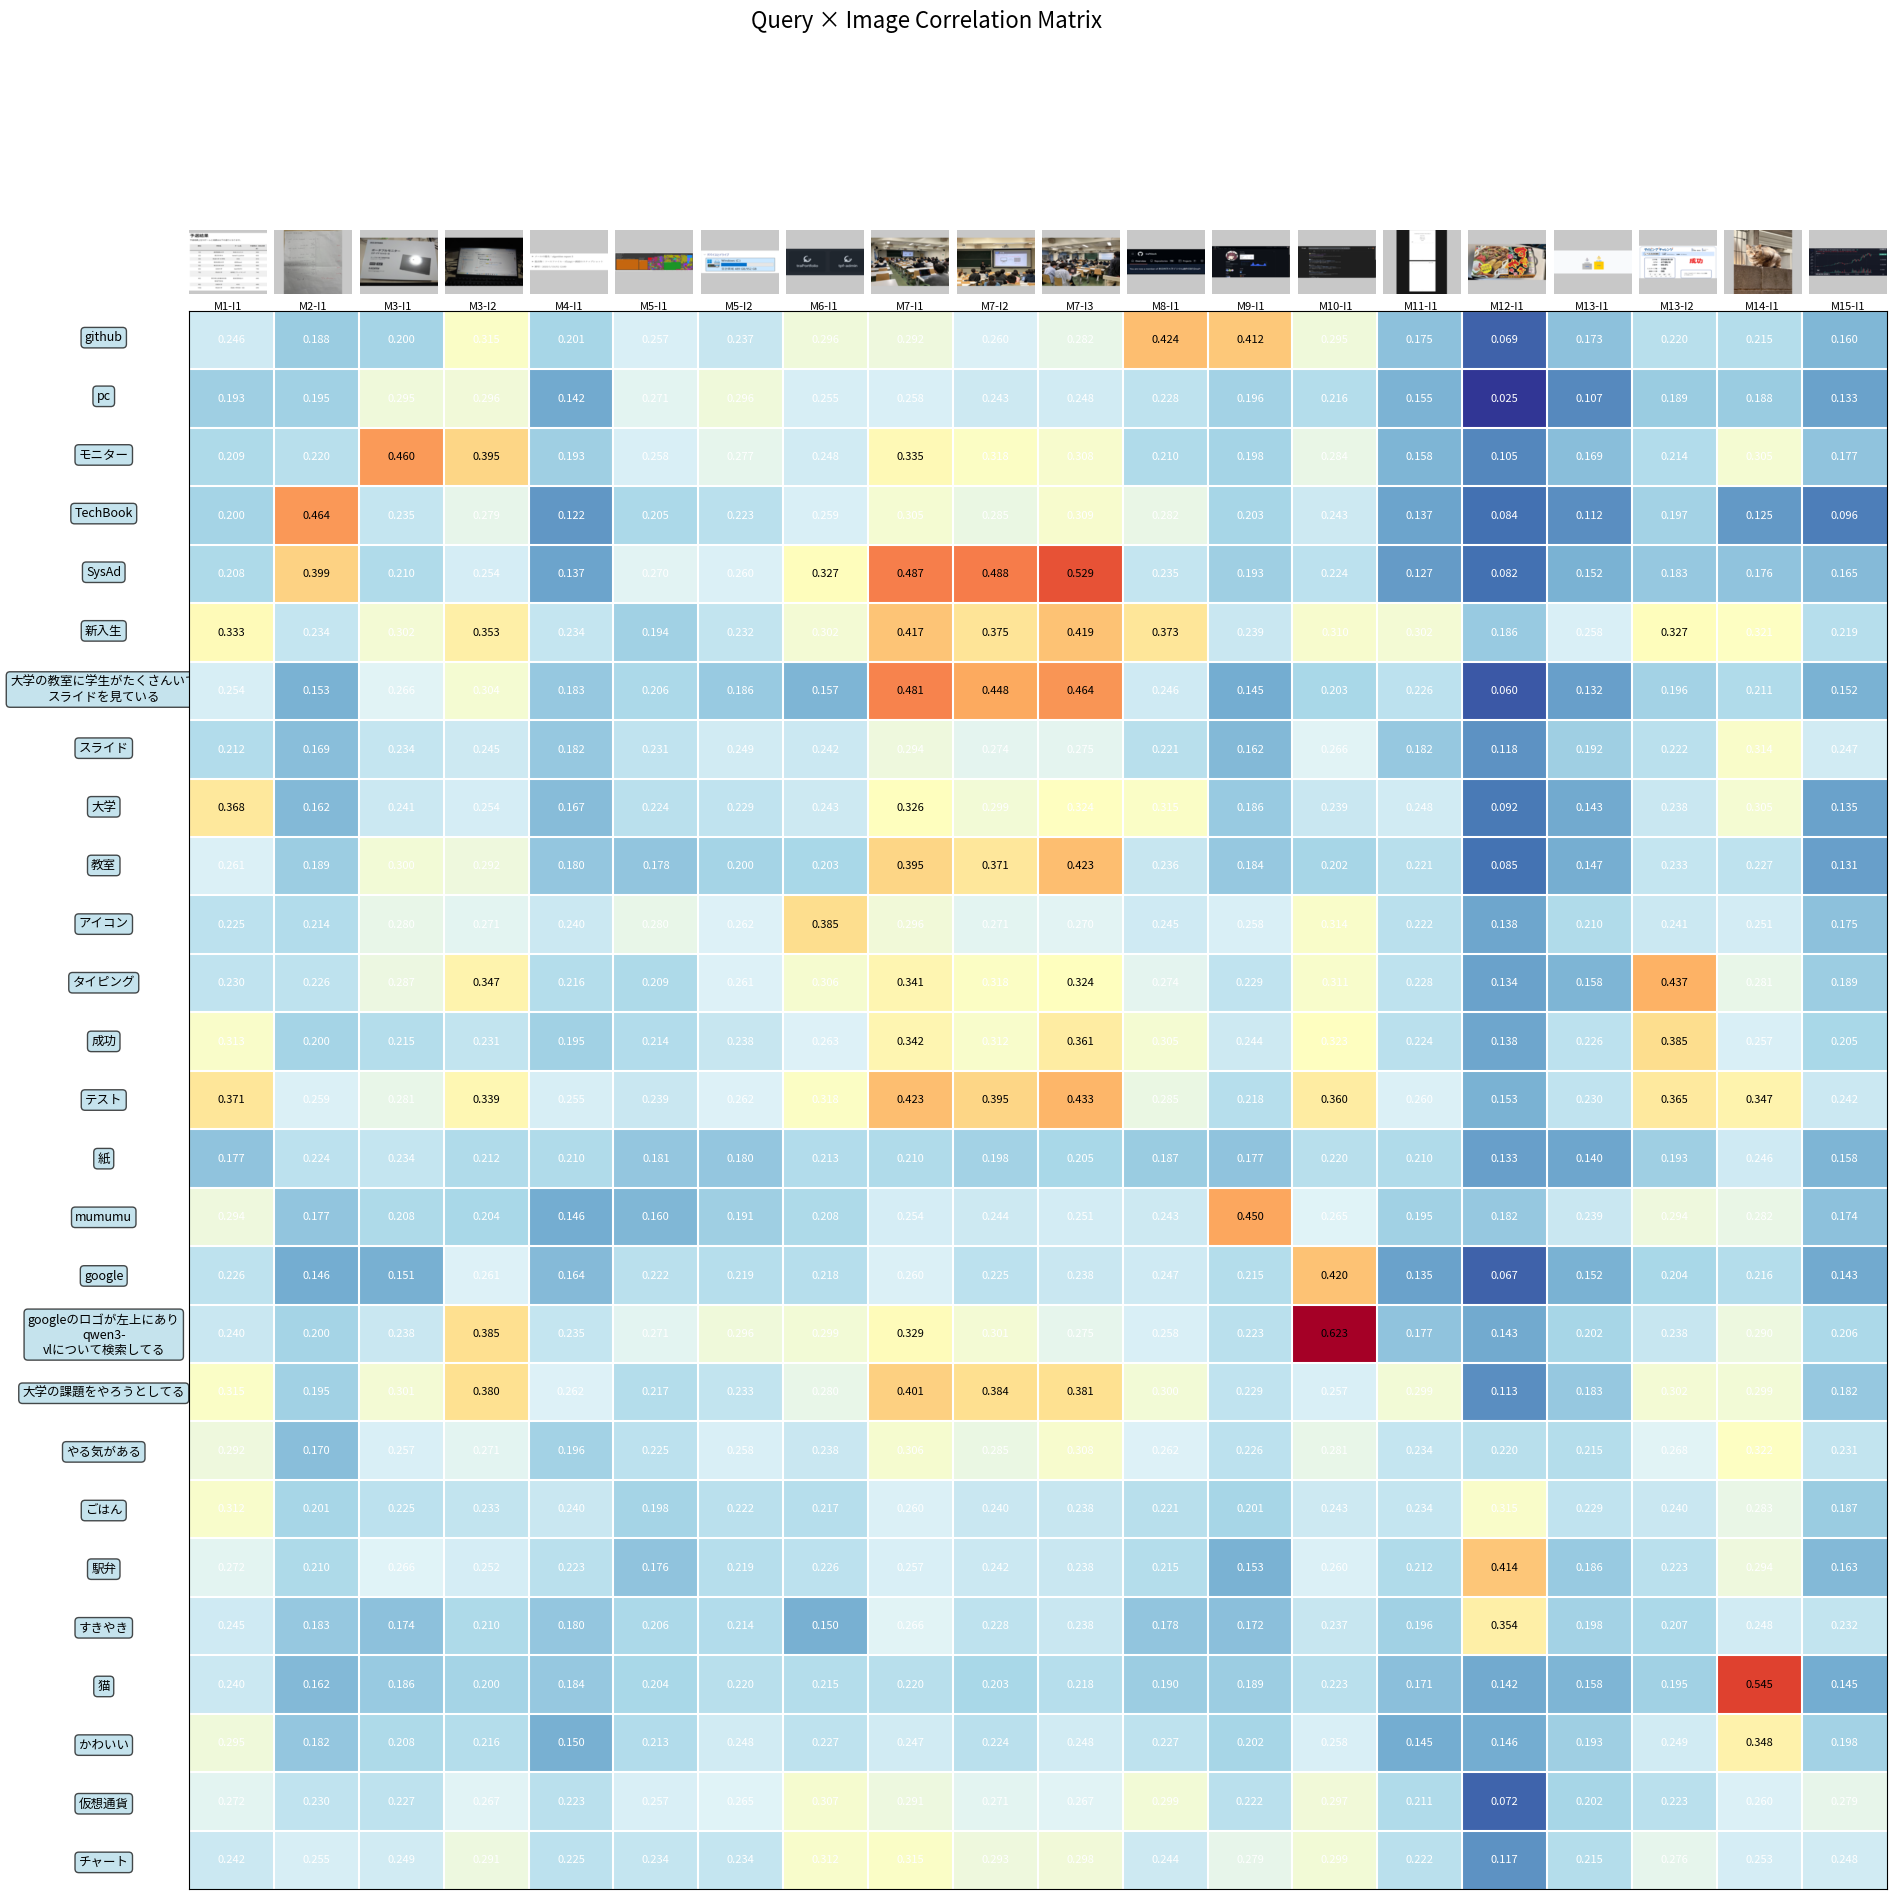

In [15]:
# クエリ×画像の相関表を作成（横軸：画像、縦軸：クエリ）
import matplotlib.gridspec as gridspec
import numpy as np
import textwrap

# クエリとドキュメントの類似度（Cell 9で計算済み）
query_doc_similarity = similarity_scores.cpu().numpy()

num_queries = len(query_texts)
num_docs = len(documents)

# 画像サムネイルを準備（表示用：横幅を統一するため正方形にリサイズ）
# 注意：LLMに渡している画像は元のサイズのままです
THUMBNAIL_SIZE = 150  # 統一サイズ（正方形）
thumbnails = []
for idx, (text, imgs) in enumerate(zip(messages, images)):
    if imgs:
        for img in imgs:
            # 画像を正方形にリサイズ（横幅を統一）
            thumb = img.copy()
            # アスペクト比を保ちつつ、短辺を基準にリサイズ
            thumb.thumbnail((THUMBNAIL_SIZE, THUMBNAIL_SIZE))
            # 正方形の画像を作成（中央に配置）
            square_img = Image.new('RGB', (THUMBNAIL_SIZE, THUMBNAIL_SIZE), (200, 200, 200))
            # 中央に配置
            x_offset = (THUMBNAIL_SIZE - thumb.width) // 2
            y_offset = (THUMBNAIL_SIZE - thumb.height) // 2
            square_img.paste(thumb, (x_offset, y_offset))
            thumbnails.append(np.array(square_img))
    else:
        # 画像がない場合は空の画像を作成
        thumbnails.append(np.ones((THUMBNAIL_SIZE, THUMBNAIL_SIZE, 3), dtype=np.uint8) * 200)

# ドキュメントラベルを作成
doc_labels = []
for idx, (text, imgs) in enumerate(zip(messages, images)):
    img_count = len(imgs)
    if img_count == 0:
        doc_labels.append(f"M{idx+1}")
    else:
        # 複数画像がある場合は、各画像ごとにラベルを作成
        for img_idx in range(img_count):
            doc_labels.append(f"M{idx+1}-I{img_idx+1}")

# グリッドスペックを使用してレイアウトを作成
fig = plt.figure(figsize=(max(20, num_docs * 1.2), max(12, num_queries * 0.8)))
gs = gridspec.GridSpec(
    num_queries + 1, num_docs + 1,
    figure=fig,
    width_ratios=[2] + [1] * num_docs,  # 縦軸はテキストのみなので幅を小さく
    height_ratios=[1.5] + [1] * num_queries,  # 縦軸は画像がないので高さを小さく
    hspace=0.1, wspace=0.1  # 画像間の隙間
)

# 左上の空白
ax_corner = fig.add_subplot(gs[0, 0])
ax_corner.axis('off')

# 上部の画像（横軸：画像）
for i in range(num_docs):
    ax_top = fig.add_subplot(gs[0, i + 1])
    ax_top.set_xlim(0, 1)
    ax_top.set_ylim(0, 1)
    if i < len(thumbnails):
        # 画像をセル全体に表示（余白なし、上下に少し余白を残してラベル用）
        ax_top.imshow(thumbnails[i], aspect='auto', extent=[0, 1, 0.15, 0.95], interpolation='bilinear')
    ax_top.axis('off')
    # ラベルを画像の下に表示（余白を最小限に）
    ax_top.text(0.5, 0.05, doc_labels[i], fontsize=8, ha='center', va='top', transform=ax_top.transAxes)

# 左側のクエリテキスト（縦軸：クエリ）- 画像は表示しない
for i in range(num_queries):
    ax_left = fig.add_subplot(gs[i + 1, 0])
    ax_left.axis('off')
    
    # クエリテキストを表示（中央配置）
    query_text = query_texts[i]
    wrapped_text = '\n'.join(textwrap.wrap(query_text, width=15))
    ax_left.text(0.5, 0.5, wrapped_text, 
                ha='center', va='center', fontsize=9,
                transform=ax_left.transAxes,
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

# ヒートマップのメイン部分
ax_main = fig.add_subplot(gs[1:, 1:])

# ヒートマップを描画
im = ax_main.imshow(
    query_doc_similarity,
    cmap='RdYlBu_r',
    vmin=query_doc_similarity.min(),
    vmax=query_doc_similarity.max(),
    aspect='auto'
)

# 各セルに数値を表示
for i in range(num_queries):
    for j in range(num_docs):
        score = query_doc_similarity[i, j]
        # スコアに応じてテキストの色を変更
        text_color = "white" if score < (query_doc_similarity.max() + query_doc_similarity.min()) / 2 else "black"
        ax_main.text(
            j, i, f'{score:.3f}',
            ha="center", va="center",
            color=text_color,
            fontsize=8
        )

# グリッド線を追加
ax_main.set_xticks(np.arange(num_docs) - 0.5, minor=True)
ax_main.set_yticks(np.arange(num_queries) - 0.5, minor=True)
ax_main.grid(which="minor", color="white", linestyle='-', linewidth=1.5)
ax_main.tick_params(which="minor", size=0)

# メジャーティックを非表示
ax_main.set_xticks([])
ax_main.set_yticks([])



plt.suptitle('Query × Image Correlation Matrix', fontsize=16, y=0.98)
plt.show()


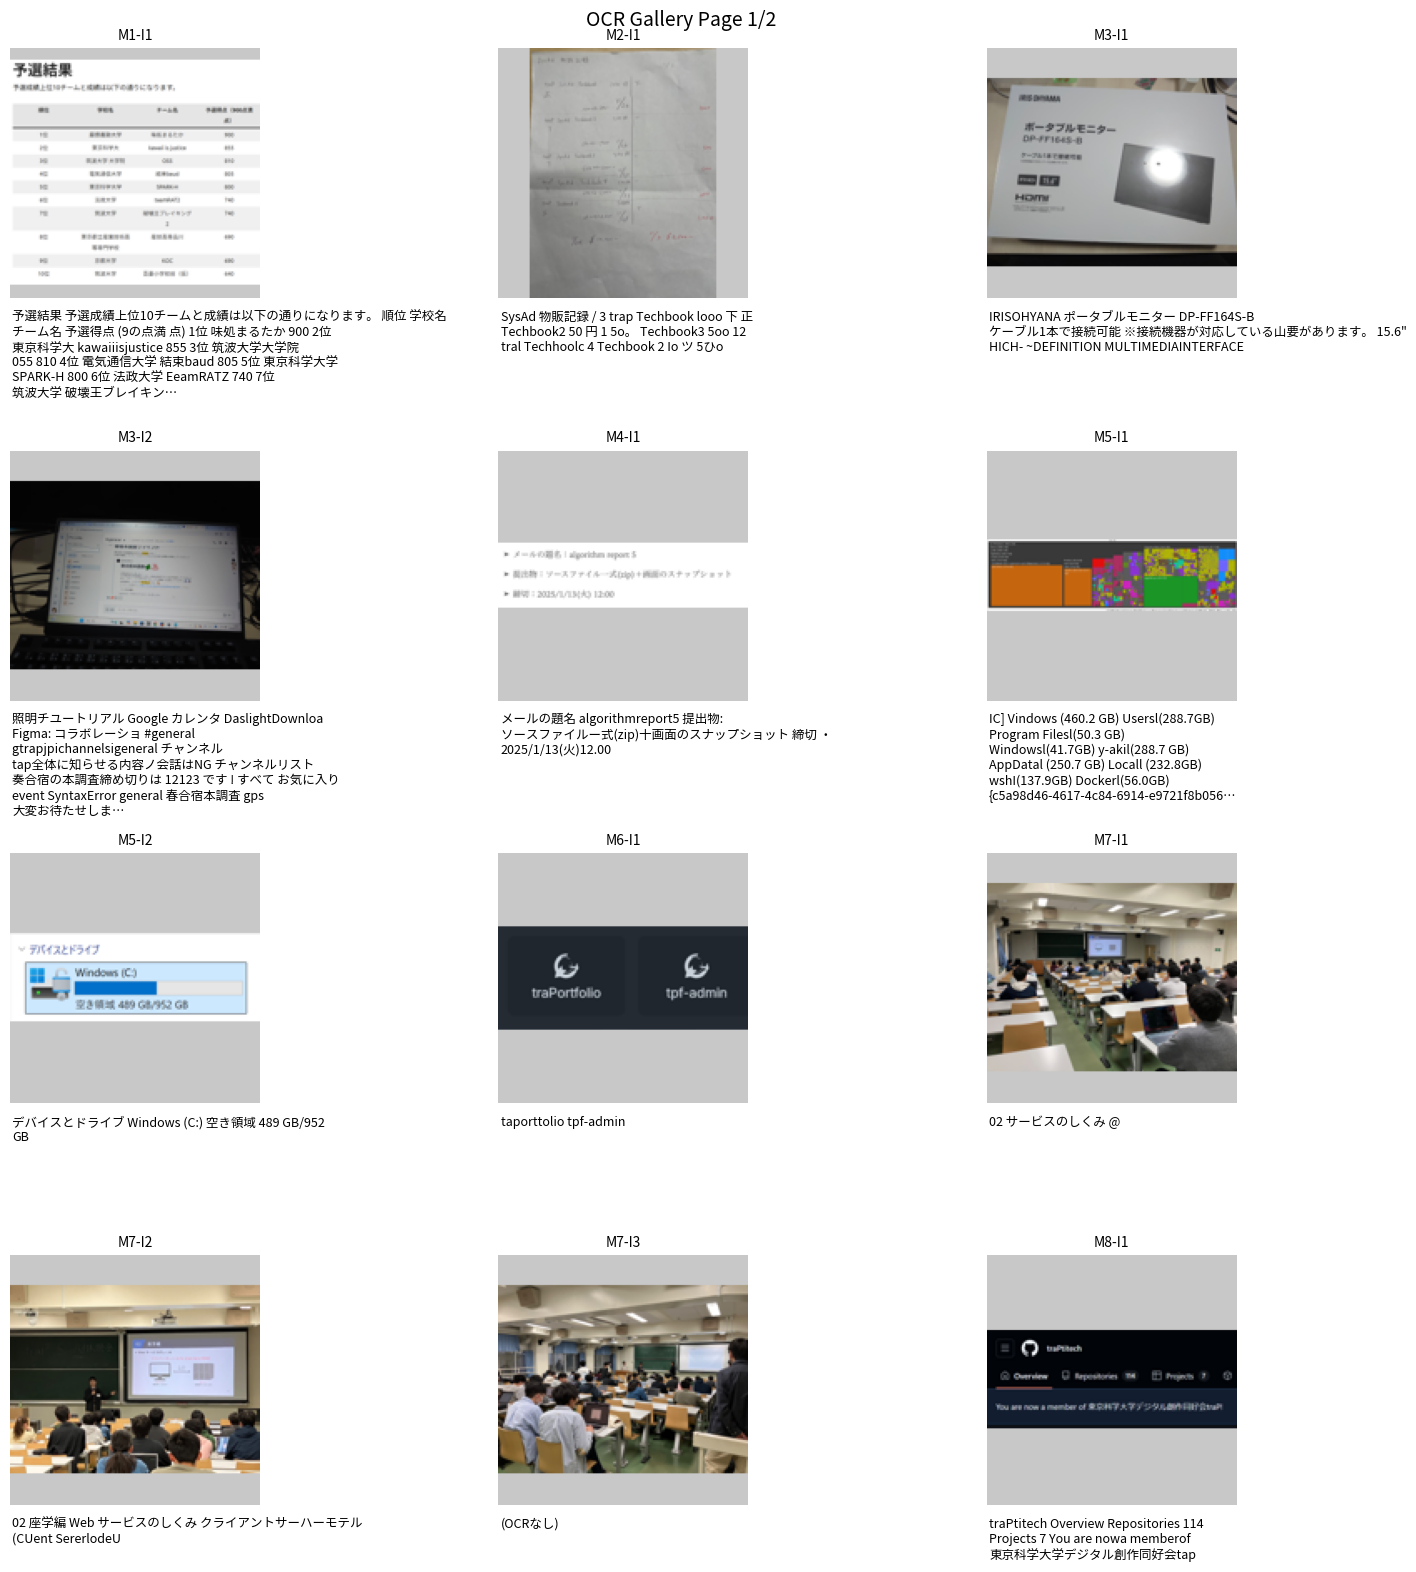

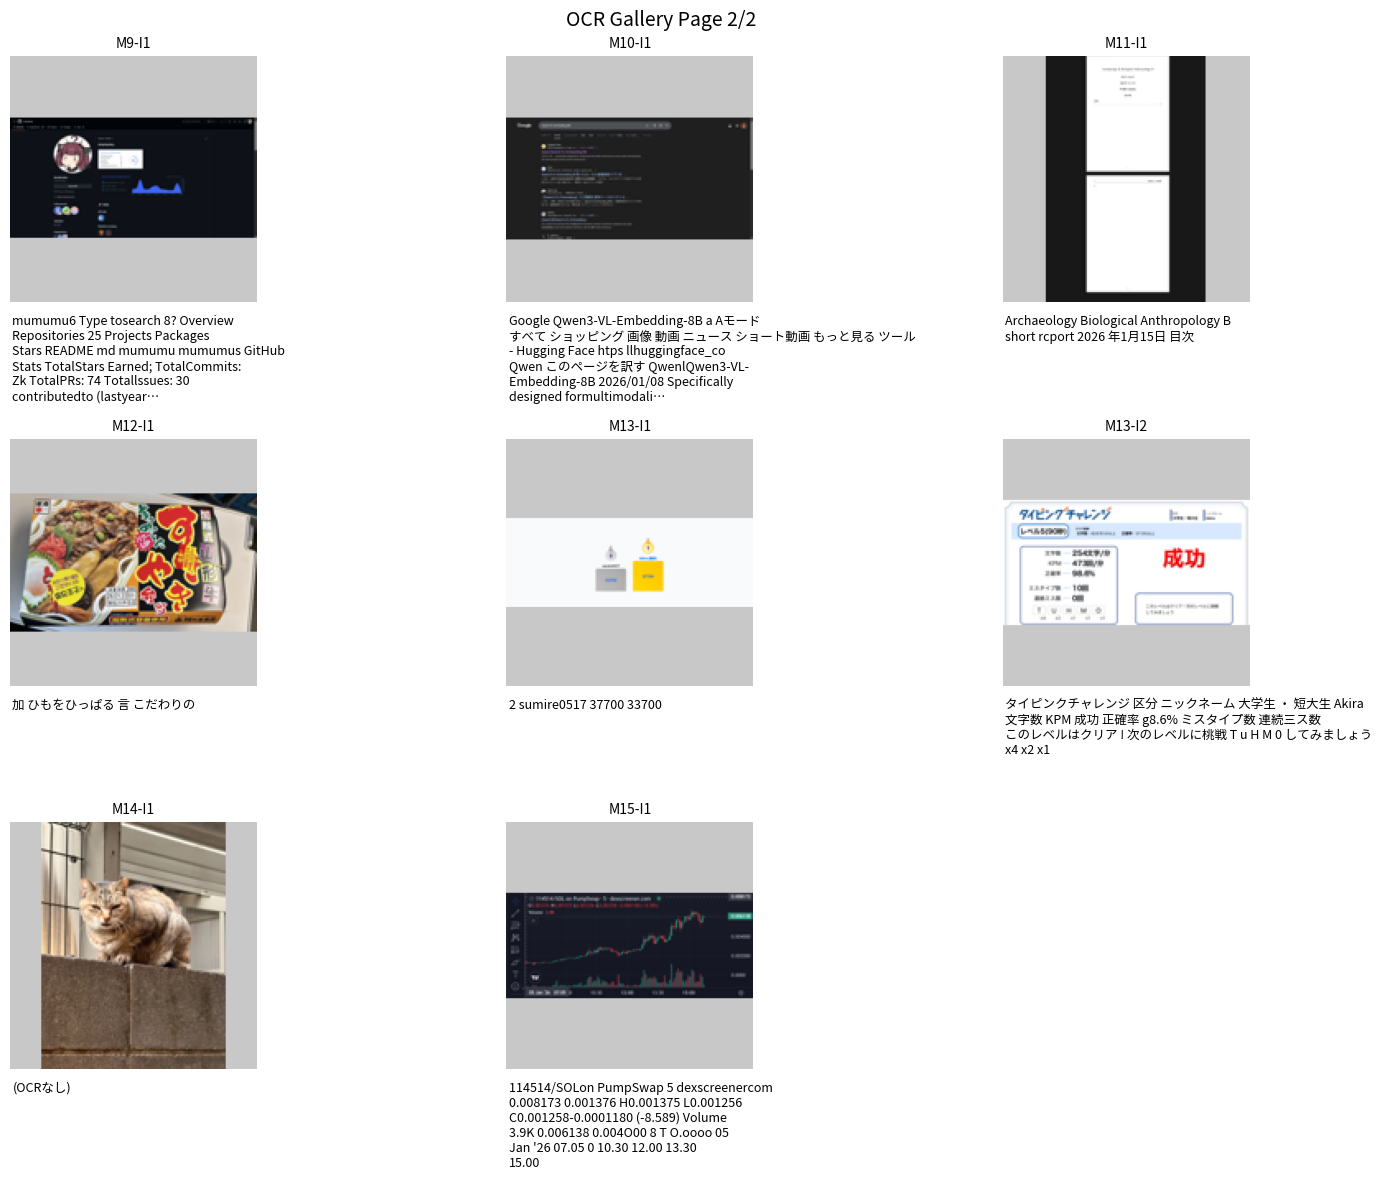

In [16]:
import matplotlib.pyplot as plt
import textwrap
import math

def show_ocr_gallery(thumbnails, labels, ocr_texts, cols=3, per_page=12, ocr_chars=250):
    assert len(thumbnails) == len(labels) == len(ocr_texts)
    n = len(labels)
    pages = math.ceil(n / per_page)

    for p in range(pages):
        start = p * per_page
        end = min(n, (p + 1) * per_page)
        m = end - start
        rows = math.ceil(m / cols)

        fig = plt.figure(figsize=(cols * 5, rows * 4))
        for k in range(m):
            doc_idx = start + k
            ax = fig.add_subplot(rows, cols, k + 1)
            ax.imshow(thumbnails[doc_idx])
            ax.axis("off")

            ocr = (ocr_texts[doc_idx] or "").strip()
            if len(ocr) > ocr_chars:
                ocr = ocr[:ocr_chars] + "…"
            if not ocr:
                ocr = "(OCRなし)"

            ax.set_title(labels[doc_idx], fontsize=10)
            ax.text(
                0.01, -0.05,
                textwrap.fill(ocr, width=38),
                transform=ax.transAxes,
                fontsize=9,
                va="top",
                ha="left",
            )

        fig.suptitle(f"OCR Gallery Page {p+1}/{pages}", fontsize=14)
        plt.tight_layout()
        plt.show()

# 実行例
show_ocr_gallery(thumbnails, labels, ocr_texts, cols=3, per_page=12, ocr_chars=250)